# Resolución Trabajo Práctico 02

## Integrantes

- Gaspar Acevedo Zain

## Carga del dataset

### Imports y carga del dataset

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [19]:
df_procesado = pd.read_csv("../dataset/sneep-2023-procesamiento.csv")

In [9]:
# Configuramos el output display con 100 filas
pd.options.display.max_rows = 100
# Configuramos el output display con 100 columnas
pd.options.display.max_columns = 100

## Paso 1 - Split del dataset

Antes de realizar operaciones tales como tratamiento de nulos, tratamiento de outliers, creación de nuevas features, entre otras, debemos separar el dataset en *train* y *test*.

### Paso 1.1 - Repaso de columnas

Comencemos repasando las columnas del dataset:

In [11]:
df_procesado.columns.tolist()

['provincia_descripcion',
 'establecimiento_descripcion',
 'edad',
 'genero_descripcion',
 'nacionalidad_descripcion',
 'estado_civil_descripcion',
 'nivel_instruccion_descripcion',
 'ultima_situacion_laboral_descripcion',
 'capacitacion_laboral_al_ingresar_descripcion',
 'ultimo_lugar_residencia_descripcion',
 'ultima_provincia_residencia_descripcion',
 'jurisdiccion_descripcion',
 'situacion_legal_descripcion',
 'establecimiento_procedencia_descripcion',
 'delito1_descripcion',
 'delito2_descripcion',
 'delito3_descripcion',
 'delito4_descripcion',
 'delito5_descripcion',
 'horas_trabajo_remunerado_descripcion',
 'participacion_programa_laboral',
 'participacion_programa_educativo_descripcion',
 'participacion_actividades_deportivas',
 'recibio_atencion_medica_ult_anio',
 'recibio_atencion_medica_ult_anio_descripcion',
 'recibio_visitas_ultimo_anio',
 'participo_alteracion_orden_ult_anio_descripcion',
 'tipo_infraccion_disciplinaria_descripcion',
 'sancion_aplicada_descripcion',
 'ca

In [12]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_laboral,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,2,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,1,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,1.0,0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como se pueder observar, quedaron las siguientes columnas correspondientes a `IDs`:

- `participacion_programa_laboral` (su descripción equivalente está en la columna `participacion_programa_educativo_descripcion`)
- `recibio_atencion_medica_ult_anio` (su descripción equivalente está en la columna `recibio_atencion_medica_ult_anio_descripcion`)

Se decide trabajar con las variables categóricas, por lo cual eliminamos aquellas que corresponden a `IDs`.

In [17]:
columnas_a_eliminar = [
    "participacion_programa_laboral",
    "recibio_atencion_medica_ult_anio"
]

In [20]:
df_procesado = df_procesado.drop(columns=columnas_a_eliminar)

In [23]:
df_procesado.columns.size

44

De esta manera, el dataset queda con *44 columnas*:

In [24]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,1.0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df_procesado["tipo_condena"].unique()

array([ 0.,  1., nan])

El siguiente paso será dividir las columnas en distintos grupos, para tratarlas en pasos posteriores según corresponda:

Columnas *numéricas*:

- `edad`
- `duracion_condena_anios`
- `duracion_condena_meses`

Columnas *booleanas*:

- `participacion_actividades_deportivas`
- `recibio_visitas_ultimo_anio`
- `tentativa_suicidio`
- `participa_programa_pre_libertad`

*Otras* columnas:

- `tipo_condena`: presenta como valores únicos a `0`, `1`, y `nan`. No se tiene suficiente información para definirla como *booleana* o *categórica*.

Columna objetivo o *target*:

- `tuvo_reduccion_pena_descripcion`

El resto de las columnas son categóricas.

In [41]:
col_numericas = [
    "edad",
    "duracion_condena_anios",
    "duracion_condena_meses"
]

col_booleanas = [
    "participacion_actividades_deportivas",
    "recibio_visitas_ultimo_anio",
    "tentativa_suicidio",
    "participa_programa_pre_libertad"
]

col_otras = [
    "tipo_condena"
]

target = "tuvo_reduccion_pena_descripcion"

col_objetivo = [target]

In [42]:
col_categoricas = list(set(df_procesado.columns) - set(col_booleanas + col_otras + col_numericas + col_objetivo))

### Paso 1.2 - Split en Train y test

In [82]:
# definimos un random_state
random_state = 649739
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(
    df_procesado.drop(columns=target),
    df_procesado[target],
    random_state=random_state,
    test_size=test_size)

## Paso 2 - Normalización y estandarización

El siguiente paso corresponde a aplicar técnicas de normalización y estandarización a las siguientes variables numéricas:

- `edad`
- `duracion_condena_anios`
- `duracion_condena_meses`

### Paso 2.1 - Normalización

Aplicamos normalización a las variables numéricas mediante la clase [MixMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.transform).

In [83]:
scaler = MinMaxScaler()
df_train_escalado = pd.DataFrame(scaler.fit_transform(X_train[col_numericas]), columns=col_numericas)
df_test_escalado = pd.DataFrame(scaler.transform(X_test[col_numericas]), columns=col_numericas)

### Paso 2.2 - Estandarización

Estandarizamos a las variables numéricas mediante la clase [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.transform).

In [84]:
standard_scaler = StandardScaler()
df_train_estandarizado = pd.DataFrame(standard_scaler.fit_transform(X_train[col_numericas]), columns=col_numericas)
df_test_estandarizado = pd.DataFrame(standard_scaler.transform(X_test[col_numericas]), columns=col_numericas)

### Paso 2.3 - Comparación mediante gráficos

In [88]:
def graficar_comparacion_transformaciones(df_original, df_normalizado, df_estandarizado, 
                                          columns, titulos = ["Original", "Normalizado (MinMax)", "Estandarizado (Z-Score)"],
                                          figsize = (10,10), colores = ["gray", "blue", "red"]):
    fig, axes = plt.subplots(nrows=len(columns), ncols=3, figsize=figsize)

    for i, col in enumerate(columns):
        sns.histplot(df_original[col], kde=True, ax=axes[i, 0], color=colores[0])
        sns.histplot(df_normalizado[col], kde=True, ax=axes[i, 1], color=colores[1])
        sns.histplot(df_estandarizado[col], kde=True, ax=axes[i, 2], color=colores[2])

        axes[i, 0].set_ylabel(col)
        for j in range(3):
            axes[i, j].set_xlabel("")
            axes[i, j].set_title(titulos[j])
    plt.tight_layout()
    plt.show()

A continuación se grafica la distribución de las variables numéricas en los dataset de `train` *original*, *normalizado* y *estandarizado*.

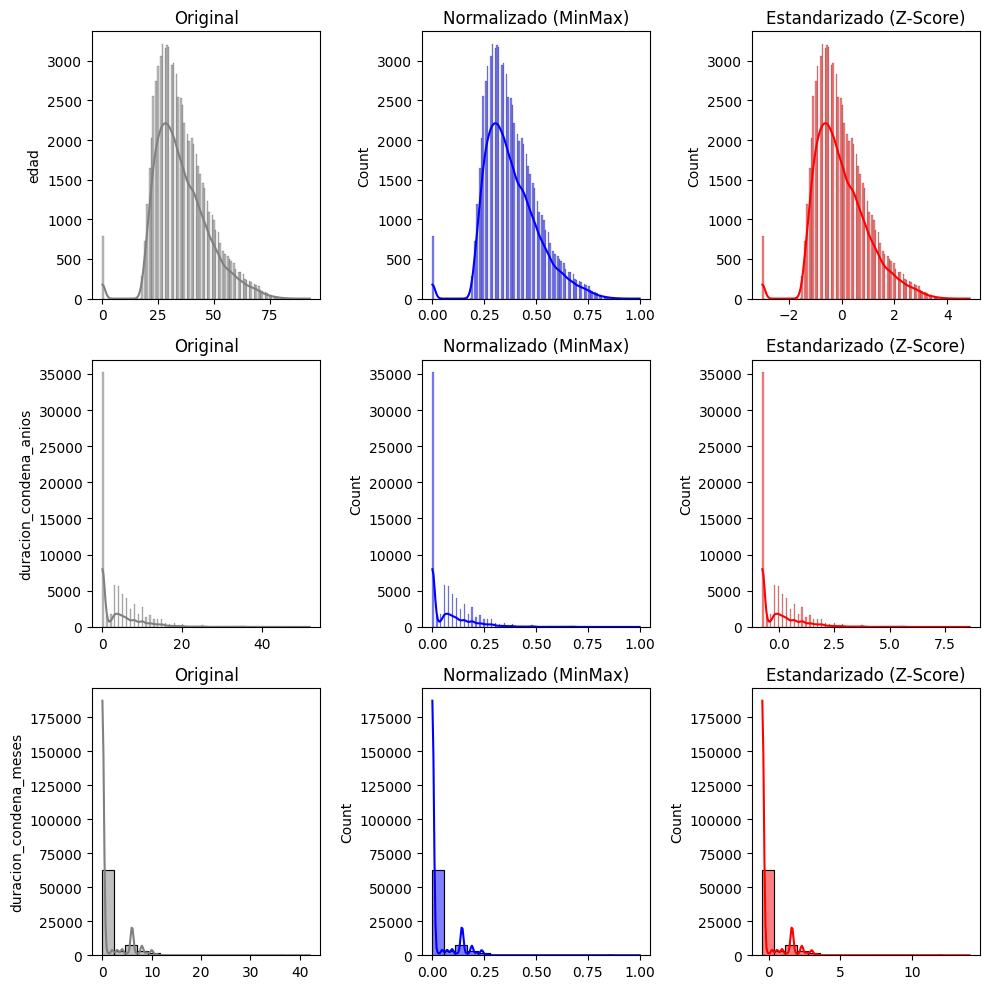

In [89]:
graficar_comparacion_transformaciones(df_original=X_train,
                                      df_normalizado=df_train_escalado,
                                      df_estandarizado=df_train_estandarizado,
                                      columns=col_numericas)

A continuación se grafica la distribución de las variables numéricas en los dataset de `test` *original*, *normalizado* y *estandarizado*.

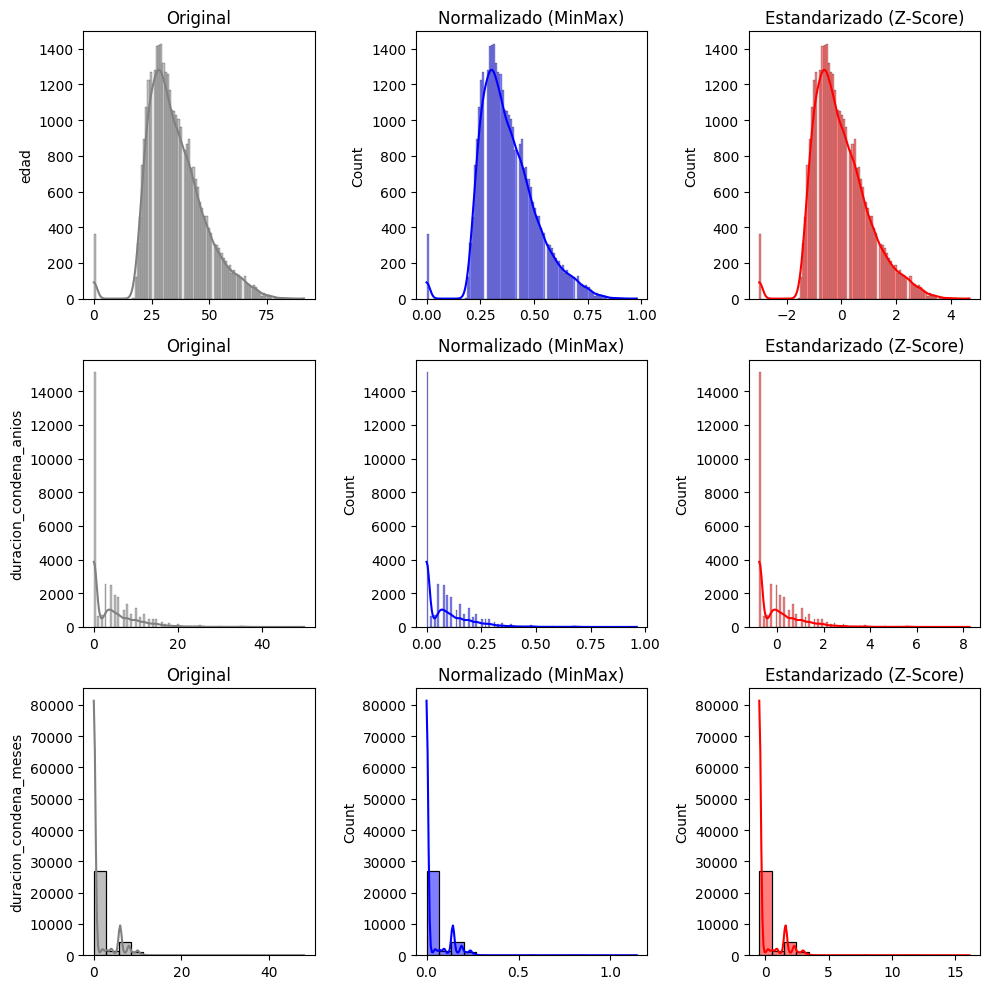

In [90]:
graficar_comparacion_transformaciones(df_original=X_test,
                                      df_normalizado=df_test_escalado,
                                      df_estandarizado=df_test_estandarizado,
                                      columns=col_numericas)

Como se puede observar en los gráficos, las distribuciones se mantienen para todas las variables, tanto al estandarizar como al normalizar los datasets de *train* y *test*.

Se opta por utilizar la estandarización de estas variables, ya que esta puede resultar útil al trabajar con algoritmos tales como `Regresión Lineal` y `SVM`, mientras que la normalización resulta útil para algoritmos tales como `KNN`, el cual es poco probable que se utilice en casos como este.

Por este motivo, reemplazaremos las columnas numéricas el los datasets *train* y *test* por sus valores `estandarizados`.

Antes de aplicar estos cambios a la variables `edad`, hay que recordar que esta variable presentaba un total de `785` datos nulos (con edad igual a cero).

Por eso, se valida que la cantidad de registros con valor mínimo de `edad` estandarizada (`-2.994274675689943`) sea también de `785`, lo cual se demuestra en las siguientes celdas:

In [102]:
df_train_estandarizado["edad"].min()

-2.994274675689943

In [100]:
len(df_train_estandarizado[df_train_estandarizado["edad"] == df_train_estandarizado["edad"].min()])

785

In [101]:
len(X_train[X_train["edad"]==0])

785

### Paso 2.4 - Reemplazo de variables numéricas *originales* por estandarizadas

Se reemplazan las columnas numéricas originales el los datasets *train* y *test* por sus valores `estandarizados`.

In [103]:
for col in col_numericas:
    X_train[col] = df_train_estandarizado[col]
    X_test[col] = df_test_estandarizado[col]